# C2 · Taller 1 — Boosting: ¿cambia el simulador o el detector de Shiro?

**Aprendizaje de Máquina · Universidad Sergio Arboleda · Semestre 26-2**
Grupo Shiro — Jose Leonardo Diazgranados, Sofía Londoño, Andrés Felipe Céspedes Rondón, Alex Duran
Docente: Hernán Darío Cruz Bueno · Sector: Energía y Medio Ambiente / IoT

---

## Qué decide este taller para Shiro

Después del parcial, dos piezas de la arquitectura de Shiro Twin tienen un modelo asignado, y los
dos se eligieron bajo la partición que decide — la temporal, con variables de retardo:

| Pieza | Modelo vigente | Cifra que hay que superar |
|---|---|---|
| **Función de transición del simulador** — qué consumo devuelve el gemelo ante un estado | Regresión lineal + retardos | R² **0,557** · MAE 28,17 Wh sobre mayo, un mes nunca visto |
| **Detector de consumo anómalo** — cuándo avisar a la persona | Random Forest + retardos | **86,9 %** de los episodios reales detectados con 3,0 avisos al día |

El boosting es la continuación natural de Random Forest: en vez de promediar árboles independientes,
los encadena, y cada árbol corrige los errores del anterior. La pregunta del taller no es cuál de los
cinco saca la mejor métrica, sino **si alguno reemplaza a un modelo vigente de Shiro**.

## Tres hipótesis, formuladas antes de mirar los resultados

1. **Los boostings de árboles no van a extrapolar.** GBM, XGBoost, LightGBM y CatBoost predicen
   sumando valores de hoja aprendidos en invierno — el mismo límite que tumbó a Random Forest en el
   parcial (sesgo de +64 Wh sobre todo mayo). Expectativa: ganan la partición aleatoria y fallan en
   la temporal.
2. **LightGBM con hojas lineales (`linear_tree=True`) sí podría.** Ajusta un modelo lineal dentro de
   cada hoja: combina la no linealidad de los árboles con la capacidad de extrapolar de la lineal.
   Es el experimento con más retorno posible para el simulador.
3. **AdaBoost será el más frágil.** Repondera los casos difíciles, y los picos de 800 Wh sin señal
   previa (el Caso A del parcial) recibirán un peso enorme.

---
## 1. Carga y preparación (idéntica al parcial)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time, warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (AdaBoostRegressor, AdaBoostClassifier, GradientBoostingRegressor,
                              GradientBoostingClassifier, RandomForestRegressor, RandomForestClassifier)
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error, f1_score, precision_score,
                             recall_score, roc_auc_score, average_precision_score, log_loss)
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor, CatBoostClassifier

RS = 42
FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": .3,
                     "savefig.bbox": "tight"})
COL = {"AdaBoost": "#a142f4", "GBM": "#12b5cb", "XGBoost": "#e8710a", "LightGBM": "#1a73e8",
       "LightGBM lineal": "#0b3d91", "CatBoost": "#d93025", "CatBoost cat.": "#f28b82",
       "Random Forest (ref.)": "#188038", "Regresión Lineal (ref.)": "#5f6368"}
print("xgboost", xgb.__version__, "· lightgbm", lgb.__version__)

xgboost 3.2.0 · lightgbm 4.7.0


In [2]:
CSV = "../../data set/energydata_complete.csv"      # ajustar si el cuaderno se mueve de carpeta
df = pd.read_csv(CSV, parse_dates=["date"])
df["hora"] = df["date"].dt.hour
df["dia_semana"] = df["date"].dt.dayofweek
df["es_fin_semana"] = (df["dia_semana"] >= 5).astype(int)
df["mes"] = df["date"].dt.month

TEMPORALES = ["hora", "dia_semana", "es_fin_semana", "mes"]
INTERIOR = [c for c in df.columns if c.startswith(("T", "RH_")) and c not in ("T_out", "RH_out", "Tdewpoint")]
CLIMA = ["T_out", "RH_out", "Press_mm_hg", "Windspeed", "Visibility", "Tdewpoint"]
FEATURES = TEMPORALES + ["lights"] + INTERIOR + CLIMA
TARGET = "Appliances"
RETARDOS = ["lag1", "lag2", "lag3", "lag6", "media_1h", "max_1h", "std_1h"]

# Partición aleatoria (sin retardos: filtrarían)
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(df[FEATURES], df[TARGET], test_size=.2, random_state=RS)
UMBRAL = np.percentile(yr_tr, 90)

# Partición temporal sin retardos
dfo = df.sort_values("date").reset_index(drop=True)
c0 = int(len(dfo) * .8)

# Partición temporal con retardos (el escenario que decide la arquitectura)
dl = dfo.copy()
for k in (1, 2, 3, 6):
    dl[f"lag{k}"] = dl[TARGET].shift(k)
dl["media_1h"] = dl[TARGET].shift(1).rolling(6).mean()
dl["max_1h"] = dl[TARGET].shift(1).rolling(6).max()
dl["std_1h"] = dl[TARGET].shift(1).rolling(6).std()
dl = dl.dropna().reset_index(drop=True)
cl = int(len(dl) * .8)

ESCENARIOS = {
    "Aleatoria": (Xr_tr, yr_tr, Xr_te, yr_te, "aleatoria"),
    "Temporal": (dfo.iloc[:c0][FEATURES], dfo.iloc[:c0][TARGET], dfo.iloc[c0:][FEATURES], dfo.iloc[c0:][TARGET],
                 "cronologica"),
    "Temporal + retardos": (dl.iloc[:cl][FEATURES + RETARDOS], dl.iloc[:cl][TARGET],
                            dl.iloc[cl:][FEATURES + RETARDOS], dl.iloc[cl:][TARGET], "cronologica"),
}
for n, (a, b, c, d_, _) in ESCENARIOS.items():
    print(f"{n:22s} entrena {len(a):6,d} · prueba {len(c):5,d} · {a.shape[1]} variables")
print(f"Umbral de anomalía: {UMBRAL:.0f} Wh")

Aleatoria              entrena 15,788 · prueba 3,947 · 29 variables
Temporal               entrena 15,788 · prueba 3,947 · 29 variables
Temporal + retardos    entrena 15,783 · prueba 3,946 · 36 variables
Umbral de anomalía: 200 Wh


---
## 2. Los cinco métodos, en lo que los distingue

Los cinco construyen un conjunto de árboles **en secuencia**: cada árbol nuevo se entrena para
corregir lo que el conjunto anterior todavía hace mal. Difieren en *qué* corrigen y *cómo*.

| Método | Qué corrige cada árbol nuevo | Lo que lo distingue |
|---|---|---|
| **AdaBoost** (1997) | Los mismos datos, **reponderados**: los ejemplos mal predichos pesan más | El primero de la familia. Muy sensible a valores extremos, porque los persigue |
| **Gradient Boosting — GBM** (2001) | Los **residuos** del conjunto (el gradiente de la pérdida) | Generaliza la idea a cualquier pérdida diferenciable. Implementación de scikit-learn, secuencial y lenta |
| **XGBoost** (2016) | Los residuos, con información de **segunda derivada** | Regularización explícita del tamaño de las hojas, paralelismo, poda posterior |
| **LightGBM** (2017) | Los residuos, construyendo el árbol **hoja a hoja** | Histogramas y crecimiento por la hoja de mayor ganancia: el más rápido. Admite hojas lineales |
| **CatBoost** (2018) | Los residuos, con **boosting ordenado** | Evita la fuga de información al codificar categóricas; las trata de forma nativa |

Frente a Random Forest, la diferencia de fondo es la dirección del error que atacan: el bosque
**reduce varianza** (promedia árboles profundos e independientes); el boosting **reduce sesgo** (suma
árboles poco profundos que se corrigen entre sí). Por eso el boosting suele ganar en precisión — y
por eso puede sobreajustar si no se detiene a tiempo.

## 3. Protocolo — las convenciones del proyecto, intactas

- **Mismas 29 variables**, mismo umbral de anomalía (percentil 90 del entrenamiento ≈ 200 Wh) y
  semilla 42.
- **Tres configuraciones:** partición aleatoria (la del curso), temporal sin retardos (el control de
  robustez de siempre) y **temporal con retardos** (la que decide la arquitectura desde el parcial).
- **El número de árboles se elige sin mirar el test:** cada modelo se entrena sobre el 85 % del
  entrenamiento y se detiene en la iteración que minimiza el error sobre el 15 % restante — un
  tramo aleatorio en la partición aleatoria y **el último 15 % en orden cronológico** en la
  temporal, para que la validación también mire hacia adelante. XGBoost, LightGBM y CatBoost lo
  hacen con parada temprana; AdaBoost y GBM, con predicciones por etapas.
- **Desbalance de clases** con la herramienta nativa de cada librería, continuación del
  `class_weight='balanced'` del SVM: pesos balanceados por muestra (AdaBoost, GBM),
  `scale_pos_weight` (XGBoost), `is_unbalance` (LightGBM) y `auto_class_weights` (CatBoost).
  En clasificación la parada temprana usa **average precision**, no log-loss (ver §5: una primera
  versión con log-loss produjo un artefacto que se declara).
- **El detector se compara con el mismo tiempo en alerta**, no con el mismo número de avisos por
  día. §5 explica por qué el presupuesto del parcial se podía ganar con trampa.
- **Las referencias se recalculan aquí mismo**, como hizo el Taller 3 con el Taller 2: Random Forest
  de 200 árboles y regresión lineal.
- Hiperparámetros de partida comunes y moderados (tasa de aprendizaje 0,05; profundidad 5–6;
  submuestreo 0,8): el taller es exploratorio y lo que se compara es el comportamiento de cada
  familia, no un ajuste fino de cada una.

In [3]:
def dividir_val(X, y, modo):
    # Validación sacada del ENTRENAMIENTO: aleatoria en la partición aleatoria, el último 15 % en la temporal
    if modo == "aleatoria":
        return train_test_split(X, y, test_size=.15, random_state=RS)
    c = int(len(X) * .85)
    return X.iloc[:c], X.iloc[c:], y.iloc[:c], y.iloc[c:]


def regresores(Xa, ya, Xv, yv):
    out = {}
    t = time.time()
    ada = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=6), n_estimators=300,
                            learning_rate=.05, random_state=RS).fit(Xa, ya)
    n = int(np.argmin([mean_squared_error(yv, p) for p in ada.staged_predict(Xv)])) + 1
    ada = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=6), n_estimators=n,
                            learning_rate=.05, random_state=RS).fit(Xa, ya)
    out["AdaBoost"] = (ada, n, time.time() - t)

    t = time.time()
    gbm = GradientBoostingRegressor(n_estimators=600, learning_rate=.05, max_depth=5, subsample=.8,
                                    random_state=RS).fit(Xa, ya)
    n = int(np.argmin([mean_squared_error(yv, p) for p in gbm.staged_predict(Xv)])) + 1
    gbm = GradientBoostingRegressor(n_estimators=n, learning_rate=.05, max_depth=5, subsample=.8,
                                    random_state=RS).fit(Xa, ya)
    out["GBM"] = (gbm, n, time.time() - t)

    t = time.time()
    m = xgb.XGBRegressor(n_estimators=3000, learning_rate=.05, max_depth=6, subsample=.8, colsample_bytree=.8,
                         early_stopping_rounds=100, random_state=RS, n_jobs=-1, verbosity=0)
    m.fit(Xa, ya, eval_set=[(Xv, yv)], verbose=False)
    out["XGBoost"] = (m, m.best_iteration + 1, time.time() - t)

    for nombre, extra in [("LightGBM", {}), ("LightGBM lineal", {"linear_tree": True})]:
        t = time.time()
        m = lgb.LGBMRegressor(n_estimators=3000, learning_rate=.05, num_leaves=31, subsample=.8, subsample_freq=1,
                              colsample_bytree=.8, random_state=RS, verbose=-1, **extra)
        m.fit(Xa, ya, eval_set=[(Xv, yv)], callbacks=[lgb.early_stopping(100, verbose=False)])
        out[nombre] = (m, m.best_iteration_, time.time() - t)

    for nombre, extra in [("CatBoost", {}), ("CatBoost cat.", {"cat_features": ["hora", "dia_semana"]})]:
        t = time.time()
        m = CatBoostRegressor(iterations=3000, learning_rate=.05, depth=6, random_seed=RS, verbose=0,
                              early_stopping_rounds=100, **extra)
        m.fit(Xa, ya, eval_set=(Xv, yv))
        out[nombre] = (m, m.get_best_iteration() + 1, time.time() - t)
    return out

---
## 4. Regresión — ¿algún boosting reemplaza al simulador?

Los cinco métodos (más dos variantes: LightGBM con hojas lineales y CatBoost con `hora` y
`dia_semana` como categóricas) se entrenan en las tres configuraciones, junto a las dos referencias
del proyecto recalculadas aquí mismo.

In [4]:
RES_REG, PRED_TEMP = {}, {}
for esc, (Xtr, ytr, Xte, yte, modo) in ESCENARIOS.items():
    Xa, Xv, ya, yv = dividir_val(Xtr, ytr, modo)
    mods = regresores(Xa, ya, Xv, yv)
    t = time.time(); rf = RandomForestRegressor(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xtr, ytr)
    mods["Random Forest (ref.)"] = (rf, 200, time.time() - t)
    t = time.time(); li = LinearRegression().fit(Xtr, ytr)
    mods["Regresión Lineal (ref.)"] = (li, None, time.time() - t)
    filas = []
    for nombre, (m, n, dt) in mods.items():
        p = m.predict(Xte)
        if esc == "Temporal + retardos":
            PRED_TEMP[nombre] = p
        filas.append({"modelo": nombre, "R²": r2_score(yte, p), "MAE (Wh)": mean_absolute_error(yte, p),
                      "RMSE (Wh)": float(np.sqrt(mean_squared_error(yte, p))), "sesgo (Wh)": float((p - yte).mean()),
                      "árboles": n, "seg": dt})
    RES_REG[esc] = pd.DataFrame(filas).set_index("modelo")
    print(f"\n=== {esc} · media real del conjunto de prueba {yte.mean():.1f} Wh ===")
    print(RES_REG[esc].round(3).to_string())
Y_TEMP = ESCENARIOS["Temporal + retardos"][3].values


=== Aleatoria · media real del conjunto de prueba 96.7 Wh ===
                            R²  MAE (Wh)  RMSE (Wh)  sesgo (Wh)  árboles      seg
modelo                                                                           
AdaBoost                 0.211    49.363     88.885       3.594     14.0   49.658
GBM                      0.467    37.167     73.043       1.541    598.0   91.694
XGBoost                  0.596    30.567     63.588       0.386   2997.0    8.884
LightGBM                 0.598    31.351     63.450      -0.131   2894.0    4.864
LightGBM lineal          0.508    33.886     70.199       0.262    339.0    1.062
CatBoost                 0.516    34.575     69.605       0.570   2989.0   18.713
CatBoost cat.            0.518    34.425     69.463       0.573   3000.0  218.207
Random Forest (ref.)     0.567    30.729     65.834       1.428    200.0    7.080
Regresión Lineal (ref.)  0.171    52.551     91.070       2.351      NaN    0.037



=== Temporal · media real del conjunto de prueba 96.4 Wh ===
                            R²  MAE (Wh)  RMSE (Wh)  sesgo (Wh)  árboles     seg
modelo                                                                          
AdaBoost                -3.463   161.539    192.324     140.222      1.0  42.487
GBM                     -0.333    82.824    105.099      51.582      9.0  43.765
XGBoost                 -0.221    77.950    100.597      46.558     19.0   0.367
LightGBM                -0.320    75.593    104.585      47.008     18.0   0.188
LightGBM lineal         -2.553   108.677    171.605      81.961     18.0   0.237
CatBoost                -0.062    65.970     93.796      33.289     23.0   0.652
CatBoost cat.           -0.149    73.779     97.573      41.299     23.0   7.943
Random Forest (ref.)    -4.459   173.185    212.706     161.089    200.0   6.439
Regresión Lineal (ref.)  0.106    50.458     86.065       3.095      NaN   0.016



=== Temporal + retardos · media real del conjunto de prueba 96.3 Wh ===
                            R²  MAE (Wh)  RMSE (Wh)  sesgo (Wh)  árboles     seg
modelo                                                                          
AdaBoost                 0.341    33.918     73.850      11.098     14.0  48.799
GBM                     -0.201    58.613     99.650      39.592     32.0  53.408
XGBoost                  0.303    45.774     75.948      26.896     49.0   0.590
LightGBM                 0.554    30.341     60.738       9.076     50.0   0.229
LightGBM lineal          0.426    37.824     68.899      12.993     73.0   0.344
CatBoost                 0.508    36.268     63.763      16.665    151.0   1.410
CatBoost cat.            0.478    41.729     65.707      24.142    180.0  18.984
Random Forest (ref.)    -0.484    76.197    110.797      63.853    200.0   8.189
Regresión Lineal (ref.)  0.557    28.166     60.543       0.457      NaN   0.026


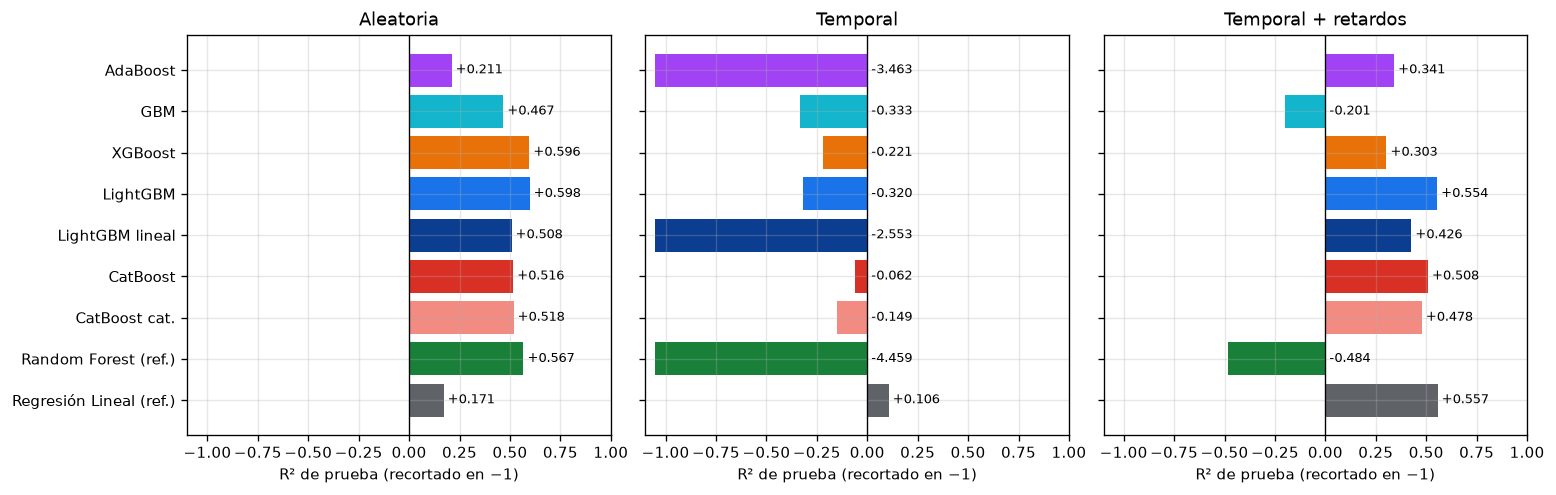

In [5]:
orden = ["AdaBoost", "GBM", "XGBoost", "LightGBM", "LightGBM lineal", "CatBoost", "CatBoost cat.",
         "Random Forest (ref.)", "Regresión Lineal (ref.)"]
fig, ax = plt.subplots(1, 3, figsize=(13, 4.2), sharey=True)
for a, esc in zip(ax, ESCENARIOS):
    r2 = RES_REG[esc].loc[orden, "R²"].clip(lower=-1.05)
    a.barh(range(len(orden)), r2, color=[COL[m] for m in orden])
    for i, (v, vr) in enumerate(zip(r2, RES_REG[esc].loc[orden, "R²"])):
        a.text(max(v, 0) + .02 if v >= 0 else .02, i, f"{vr:+.3f}", va="center", fontsize=7.5)
    a.axvline(0, color="k", lw=.8)
    a.set(title=esc, xlim=(-1.1, 1.0), xlabel="R² de prueba (recortado en −1)")
ax[0].set_yticks(range(len(orden)), orden)
ax[0].invert_yaxis()
plt.tight_layout(); plt.savefig(FIG / "B1_r2_escenarios.png"); plt.show()

### Lo que dicen las tres configuraciones

**Partición aleatoria: el boosting gana, como se esperaba.** LightGBM (R² 0,598) y XGBoost (0,596)
superan a Random Forest (0,567): LightGBM es el mejor regresor del proyecto en esta partición. Pero
hay una señal que conviene leer: XGBoost, LightGBM y CatBoost llegaron al tope de 3.000 árboles sin
que la parada temprana se activara. La validación —un 15 % aleatorio del entrenamiento— seguía
mejorando con cada árbol, porque sus vecinos de diez minutos están en el entrenamiento. Es la
autocorrelación de la advertencia §8 hecha visible: en la partición temporal, la misma parada temprana
corta entre 1 y 180 árboles.

**Temporal sin retardos: todos los modelos de árboles colapsan** (R² entre −0,06 y −4,46), y la
regresión lineal sigue siendo la única positiva (+0,106). GBM, XGBoost, LightGBM y CatBoost colapsan
menos que el bosque (entre −0,06 y −0,33 frente a −4,46) porque la validación cronológica los detiene
a los pocos árboles, antes de que memoricen el invierno. AdaBoost (−3,46) y las hojas lineales
(−2,55) no se salvan.

**Temporal con retardos —la que decide—: LightGBM empata con la lineal, pero no la supera.** R² 0,554
frente a 0,557, con un MAE mayor (30,34 frente a 28,17 Wh) y un sesgo de +9,1 Wh frente a +0,5. El
resto de la familia se reparte entre −0,20 (GBM) y 0,51 (CatBoost): con hiperparámetros equivalentes,
los boostings dan resultados muy dispares fuera de muestra, mientras que la lineal es estable.

**Veredicto de las hipótesis:**

- **H1 — los boostings de árboles no extrapolan: confirmada a medias.** Con retardos, LightGBM se
  acerca a la lineal; pero todos los modelos de árboles conservan un sesgo positivo sobre mayo (de
  +9 a +64 Wh). La sección 4.3 identifica de dónde sale.
- **H2 — las hojas lineales de LightGBM extrapolan: refutada.** Empeoran el resultado (0,426 frente a
  0,554 con retardos) y sin retardos son desastrosas (−2,553 frente a −0,320): extrapolan en línea
  recta justo las relaciones que no se sostienen en mayo.
- **H3 — AdaBoost es el más frágil: confirmada en regresión.** La validación elige 14, 1 y 14
  árboles en las tres configuraciones: cada árbol adicional lo empeora. Es coherente con su mecanismo
  —repondera los picos más difíciles hasta que dominan el ajuste—, y en la partición aleatoria queda
  último entre los boostings (0,211).
- **La hora como categórica en CatBoost no aporta** (0,518 frente a 0,516 en la aleatoria; 0,478
  frente a 0,508 en la temporal con retardos) y multiplica el tiempo de entrenamiento. Los árboles ya
  cortan la hora donde conviene: el pendiente de «codificar la hora» solo aplica a modelos de
  distancia como KNN.

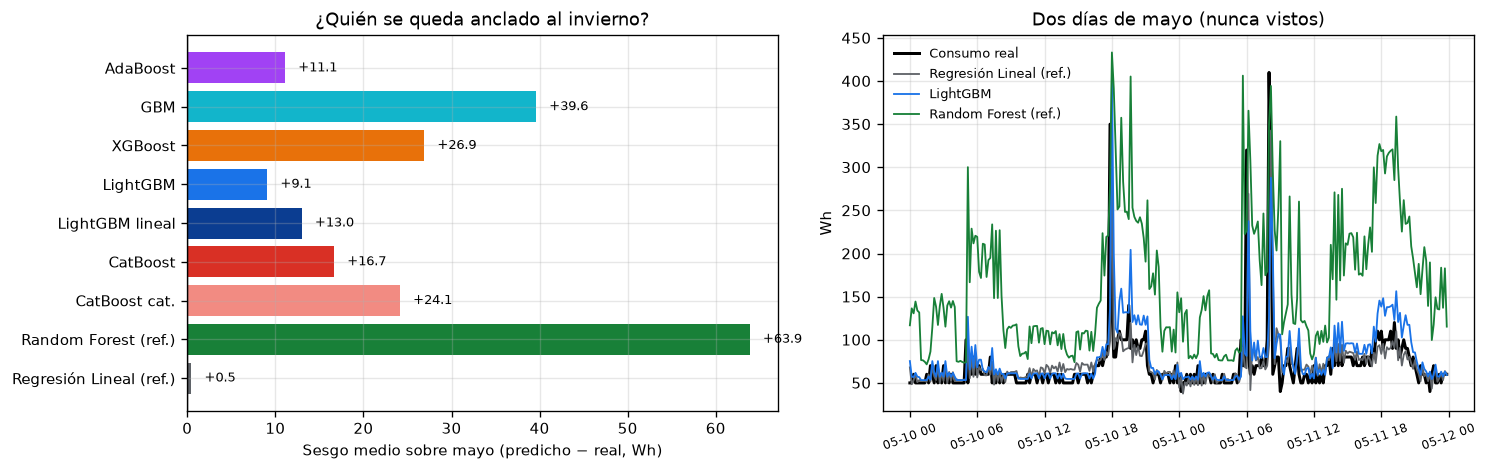

In [6]:
# Hipótesis 1: el sesgo de extrapolación. ¿Qué nivel medio predice cada modelo sobre mayo?
res = RES_REG["Temporal + retardos"].loc[orden]
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4))
ax[0].barh(range(len(orden)), res["sesgo (Wh)"], color=[COL[m] for m in orden])
for i, v in enumerate(res["sesgo (Wh)"]):
    ax[0].text(v + (1.5 if v >= 0 else -1.5), i, f"{v:+.1f}", va="center", ha="left" if v >= 0 else "right", fontsize=8)
ax[0].axvline(0, color="k", lw=.8)
ax[0].set_yticks(range(len(orden)), orden); ax[0].invert_yaxis()
ax[0].set(xlabel="Sesgo medio sobre mayo (predicho − real, Wh)", title="¿Quién se queda anclado al invierno?")

dias = dl.iloc[cl:]["date"]
v = (dias >= "2016-05-10") & (dias < "2016-05-12")
ax[1].plot(dias[v], Y_TEMP[v.values], color="black", lw=1.8, label="Consumo real")
for nombre in ["Regresión Lineal (ref.)", "LightGBM", "Random Forest (ref.)"]:
    ax[1].plot(dias[v], PRED_TEMP[nombre][v.values], color=COL[nombre], lw=1.1, label=nombre)
ax[1].set(ylabel="Wh", title="Dos días de mayo (nunca vistos)")
ax[1].tick_params(axis="x", labelsize=7, rotation=20)
ax[1].legend(frameon=False, fontsize=7.5)
plt.tight_layout(); plt.savefig(FIG / "B2_sesgo_mayo.png"); plt.show()

Todos los modelos de árboles **sobreestiman mayo**; la lineal no. Y la sobreestimación no se explica
con la idea del parcial de que el bosque «solo puede promediar valores de invierno»: la media de
consumo del entrenamiento es de unos 98 Wh y la de mayo de 96, pero los árboles predicen entre 105 y
160 Wh — por encima de cualquier promedio que hayan visto. Siguen anclados al invierno, pero no a su
promedio: aplican a mayo una regla aprendida en invierno que ya no vale. La sección 4.3 identifica cuál.

### 4.3 Diagnóstico: ¿qué empuja a los árboles a sobreestimar mayo?

Se compara la temperatura interior de mayo con la del entrenamiento, y se reentrena LightGBM quitando
distintos grupos de variables para ver cuál elimina el sesgo.

Temperatura interior media: entrenamiento 20.16 °C · mayo 23.44 °C
Lecturas de mayo más cálidas que la lectura MÁS cálida del entrenamiento: 71.9 %

En ENTRENAMIENTO — consumo medio por quintil de temperatura interior (Wh):
Q1 (fría)       87.8
Q2              98.3
Q3              92.1
Q4              98.0
Q5 (cálida)    113.9

Acoplamiento T interior ~ T exterior: entrenamiento +0.497 · mayo +0.656



¿Qué pasa si se quitan las temperaturas?
                                       n  LightGBM R²  LightGBM sesgo  Lineal R²  Lineal sesgo
temporal     variables                                                                        
sin retardos 29 variables             29       -0.320          47.008      0.106         3.095
             sin temperaturas         18        0.110           3.775      0.074         6.331
             sin sensores interiores  11        0.092          -2.750      0.031         3.895
             sin mes                  28        0.024          24.439      0.099         8.065
con retardos 29 variables             36        0.554           9.076      0.557         0.457
             sin temperaturas         25        0.561           4.107      0.559        -1.069
             sin sensores interiores  18        0.561           4.027      0.560         1.035
             sin mes                  35        0.537          10.740      0.556         1.703


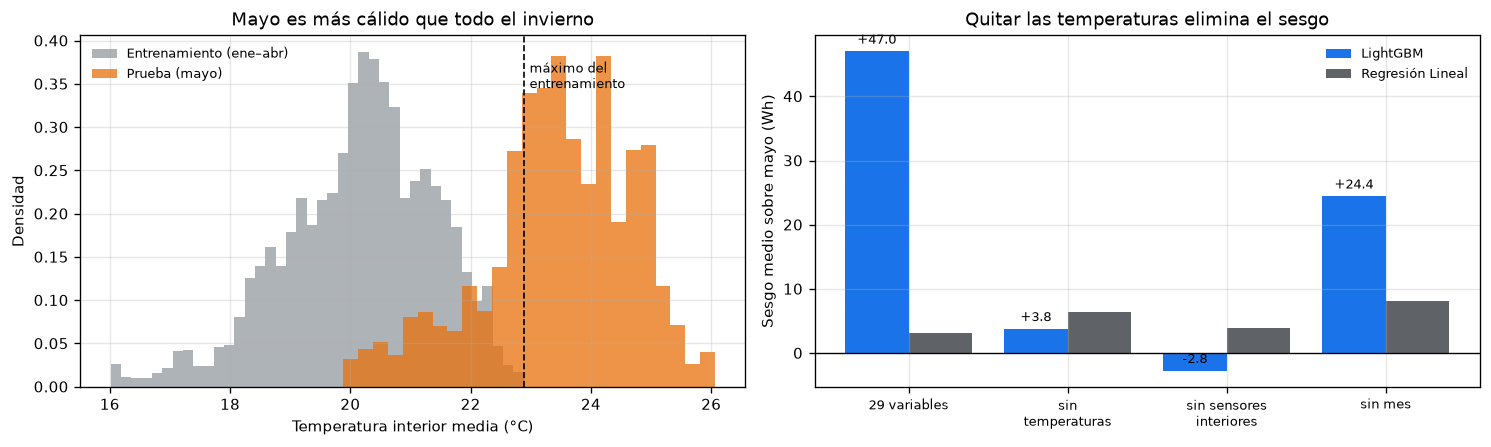

In [7]:
# Diagnóstico: ¿qué empuja a los árboles a sobreestimar mayo?
T_INT = [f"T{i}" for i in range(1, 10) if i != 6]         # T6 mide fuera del edificio (lado norte)
tr, te = dfo.iloc[:c0], dfo.iloc[c0:]
ti_tr, ti_te = tr[T_INT].mean(axis=1), te[T_INT].mean(axis=1)
print(f"Temperatura interior media: entrenamiento {ti_tr.mean():.2f} °C · mayo {ti_te.mean():.2f} °C")
print(f"Lecturas de mayo más cálidas que la lectura MÁS cálida del entrenamiento: {(ti_te > ti_tr.max()).mean() * 100:.1f} %")
quint = tr.groupby(pd.qcut(ti_tr, 5, labels=["Q1 (fría)", "Q2", "Q3", "Q4", "Q5 (cálida)"]), observed=True)[TARGET].mean()
print("\nEn ENTRENAMIENTO — consumo medio por quintil de temperatura interior (Wh):")
print(quint.round(1).to_string())
print(f"\nAcoplamiento T interior ~ T exterior: entrenamiento {np.corrcoef(ti_tr, tr['T_out'])[0, 1]:+.3f} · "
      f"mayo {np.corrcoef(ti_te, te['T_out'])[0, 1]:+.3f}")

SIN_T = [c for c in FEATURES if c not in [f"T{i}" for i in range(1, 10)] + ["T_out", "Tdewpoint"]]
SIN_INT = [c for c in FEATURES if c not in INTERIOR]
SIN_MES = [c for c in FEATURES if c != "mes"]
CONJ = {"29 variables": FEATURES, "sin temperaturas": SIN_T, "sin sensores interiores": SIN_INT, "sin mes": SIN_MES}
filas = []
for etiqueta, extra, datos, corte in [("sin retardos", [], dfo, c0), ("con retardos", RETARDOS, dl, cl)]:
    for nombre, cols in CONJ.items():
        cols = cols + extra
        Xtr_, ytr_ = datos.iloc[:corte][cols], datos.iloc[:corte][TARGET]
        Xte_, yte_ = datos.iloc[corte:][cols], datos.iloc[corte:][TARGET]
        Xa_, Xv_, ya_, yv_ = dividir_val(Xtr_, ytr_, "cronologica")
        m = lgb.LGBMRegressor(n_estimators=3000, learning_rate=.05, num_leaves=31, subsample=.8, subsample_freq=1,
                              colsample_bytree=.8, random_state=RS, verbose=-1)
        m.fit(Xa_, ya_, eval_set=[(Xv_, yv_)], callbacks=[lgb.early_stopping(100, verbose=False)])
        p = m.predict(Xte_); pl = LinearRegression().fit(Xtr_, ytr_).predict(Xte_)
        filas.append({"temporal": etiqueta, "variables": nombre, "n": len(cols),
                      "LightGBM R²": r2_score(yte_, p), "LightGBM sesgo": float((p - yte_).mean()),
                      "Lineal R²": r2_score(yte_, pl), "Lineal sesgo": float((pl - yte_).mean())})
DIAG = pd.DataFrame(filas).set_index(["temporal", "variables"])
print("\n¿Qué pasa si se quitan las temperaturas?")
print(DIAG.round(3).to_string())

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].hist(ti_tr, bins=40, color="#9aa0a6", alpha=.8, density=True, label="Entrenamiento (ene–abr)")
ax[0].hist(ti_te, bins=25, color="#e8710a", alpha=.75, density=True, label="Prueba (mayo)")
ax[0].axvline(ti_tr.max(), color="k", ls="--", lw=1)
ax[0].text(ti_tr.max() + .1, ax[0].get_ylim()[1] * .85, "máximo del\nentrenamiento", fontsize=7.5)
ax[0].set(xlabel="Temperatura interior media (°C)", ylabel="Densidad", title="Mayo es más cálido que todo el invierno")
ax[0].legend(frameon=False, fontsize=7.5, loc="upper left")
d0 = DIAG.xs("sin retardos")
ax[1].bar(np.arange(4) - .2, d0["LightGBM sesgo"], .4, color="#1a73e8", label="LightGBM")
ax[1].bar(np.arange(4) + .2, d0["Lineal sesgo"], .4, color="#5f6368", label="Regresión Lineal")
for i, v in enumerate(d0["LightGBM sesgo"]):
    ax[1].text(i - .2, v + 1.2, f"{v:+.1f}", ha="center", fontsize=8)
ax[1].axhline(0, color="k", lw=.8)
ax[1].set_xticks(range(4), ["29 variables", "sin\ntemperaturas", "sin sensores\ninteriores", "sin mes"], fontsize=8)
ax[1].set(ylabel="Sesgo medio sobre mayo (Wh)", title="Quitar las temperaturas elimina el sesgo")
ax[1].legend(frameon=False, fontsize=7.5)
plt.tight_layout(); plt.savefig(FIG / "B5_temperatura.png"); plt.show()

**La causa: la temperatura interior cambia de significado con la estación.**

**Mayo es más cálido que todo el invierno.** La temperatura interior media pasa de 20,2 °C en el
entrenamiento a 23,4 °C en mayo, y el **71,9 % de las lecturas de mayo son más cálidas que la
lectura más cálida del entrenamiento**. Un modelo de árboles no puede extrapolar: cualquier lectura
por encima de ese máximo cae en las hojas de la casa más cálida del invierno.

**Y en invierno, la casa más cálida era la que más consumía.** El quintil más cálido tiene un consumo
medio de 113,9 Wh frente a 87,8 del más frío. El árbol aprendió «casa cálida → consumo alto», y en
mayo aplica esa regla a una casa que está cálida por otra razón.

**La prueba: sin temperaturas, el colapso desaparece.** LightGBM sin retardos pasa de R² −0,320 y
sesgo +47 Wh a **R² +0,110 y sesgo +3,8 Wh** — al nivel de la lineal. Quitar el mes, en cambio, no lo
arregla: el problema no es el mes nunca visto sino las temperaturas nunca vistas. Con retardos, quitar
las temperaturas también mejora a LightGBM (de 0,554 a 0,561) y reduce su sesgo a la mitad.

**Por qué «casa cálida» significa cosas distintas.** En invierno, el calor extra dentro de la casa
viene en buena parte de los propios aparatos: la secadora calienta la lavandería y el horno la cocina.
Es coherente con dos resultados anteriores del proyecto —el Caso C del parcial, con la lavandería a
26,2 °C veinte minutos antes de un pico de 900 Wh, y la humedad de la lavandería (RH_3) que distinguía
los días de carga alta en el taller de K-Means—. En mayo la casa está cálida por el clima: el
acoplamiento entre temperatura interior y exterior sube de 0,50 a 0,66. La misma variable, con otro
significado. (Coherente con, no prueba de: la causalidad no se puede establecer con estos datos.)

> **Qué cambia en Shiro.** La función de transición **no debe predecir el consumo a partir de las
> temperaturas interiores con un modelo que no extrapola**. La temperatura interior sigue en el estado
> del MDP —es imprescindible para la penalización de confort de la recompensa—, pero como variable de
> confort, no como predictor de consumo. Esto también precisa el hallazgo 11 del parcial: el bosque no
> fallaba solo por «promediar el invierno», sino por enviar a mayo, con temperaturas nunca vistas, a
> las hojas de mayor actividad del invierno.

---
## 5. Clasificación — ¿algún boosting reemplaza al detector?

Cada librería corrige el desbalance con su herramienta nativa, y el número de árboles se elige por
**average precision** sobre la validación (el área bajo la curva precisión–recall, que no depende del
umbral ni de la calibración). Se evalúa primero con las métricas del curso, por lectura, y después
como lo usaría Shiro: **por episodio, con el mismo tiempo en alerta**.

In [8]:
def clasificadores(Xa, ca, Xv, cv):
    # Parada temprana por average precision: no depende de la calibración que introduce el balanceo
    out = {}
    sw = compute_sample_weight("balanced", ca)
    t = time.time()
    ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=300, learning_rate=.1,
                             random_state=RS).fit(Xa, ca, sample_weight=sw)
    n = int(np.argmax([average_precision_score(cv, p[:, 1]) for p in ada.staged_predict_proba(Xv)])) + 1
    ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3), n_estimators=n, learning_rate=.1,
                             random_state=RS).fit(Xa, ca, sample_weight=sw)
    out["AdaBoost"] = (ada, n, time.time() - t)

    t = time.time()
    gbm = GradientBoostingClassifier(n_estimators=600, learning_rate=.05, max_depth=4, subsample=.8,
                                     random_state=RS).fit(Xa, ca, sample_weight=sw)
    n = int(np.argmax([average_precision_score(cv, p[:, 1]) for p in gbm.staged_predict_proba(Xv)])) + 1
    gbm = GradientBoostingClassifier(n_estimators=n, learning_rate=.05, max_depth=4, subsample=.8,
                                     random_state=RS).fit(Xa, ca, sample_weight=sw)
    out["GBM"] = (gbm, n, time.time() - t)

    t = time.time()
    m = xgb.XGBClassifier(n_estimators=3000, learning_rate=.05, max_depth=5, subsample=.8, colsample_bytree=.8,
                          scale_pos_weight=(ca == 0).sum() / (ca == 1).sum(), early_stopping_rounds=100,
                          eval_metric="aucpr", random_state=RS, n_jobs=-1, verbosity=0)
    m.fit(Xa, ca, eval_set=[(Xv, cv)], verbose=False)
    out["XGBoost"] = (m, m.best_iteration + 1, time.time() - t)

    t = time.time()
    m = lgb.LGBMClassifier(n_estimators=3000, learning_rate=.05, num_leaves=31, subsample=.8, subsample_freq=1,
                           colsample_bytree=.8, is_unbalance=True, metric="average_precision",
                           random_state=RS, verbose=-1)
    m.fit(Xa, ca, eval_set=[(Xv, cv)], callbacks=[lgb.early_stopping(100, verbose=False)])
    out["LightGBM"] = (m, m.best_iteration_, time.time() - t)

    t = time.time()
    m = CatBoostClassifier(iterations=3000, learning_rate=.05, depth=6, auto_class_weights="Balanced",
                           eval_metric="PRAUC", random_seed=RS, verbose=0, early_stopping_rounds=100)
    m.fit(Xa, ca, eval_set=(Xv, cv))
    out["CatBoost"] = (m, m.get_best_iteration() + 1, time.time() - t)
    return out


def episodios(b, gap=3):
    idx = np.where(b == 1)[0]
    if len(idx) == 0: return []
    return np.split(idx, np.where(np.diff(idx) > gap)[0] + 1)


fechas_t = dl.iloc[cl:]["date"].values
DIAS_T = (pd.Timestamp(fechas_t[-1]) - pd.Timestamp(fechas_t[0])).total_seconds() / 86400

def evaluar_alertas(b, cte):
    # b: 1 = lectura en alerta. Devuelve lo que la persona vive: avisos, cobertura, falsos, duración
    cb = np.asarray(cte); ep_r = episodios(cb); ix_r = set(np.concatenate(ep_r)); ea = episodios(b)
    return {"avisos/día": len(ea) / DIAS_T,
            "eventos detectados %": sum(1 for e in ep_r if any(len(set(e) & set(a)) > 0 for a in ea)) / len(ep_r) * 100,
            "avisos falsos %": (len(ea) - sum(1 for a in ea if ix_r & set(a))) / max(len(ea), 1) * 100,
            "duración media (min)": float(np.mean([len(a) for a in ea]) * 10) if ea else 0.0,
            "tiempo en alerta %": b.mean() * 100}

def con_presupuesto(pr, cte, pct):
    # Marca en alerta exactamente el pct % de lecturas con mayor probabilidad: mismo tiempo en alerta para todos
    return evaluar_alertas((pr >= np.quantile(pr, 1 - pct / 100)).astype(int), cte)

### 5.1 Métricas del curso, por lectura

In [9]:
RES_CLF, PROBA_T = {}, {}
for esc in ("Aleatoria", "Temporal + retardos"):
    Xtr, ytr, Xte, yte, modo = ESCENARIOS[esc]
    ctr, cte = (ytr > UMBRAL).astype(int), (yte > UMBRAL).astype(int)
    Xa, Xv, ca, cv = dividir_val(Xtr, ctr, modo)
    mods = clasificadores(Xa, ca, Xv, cv)
    t = time.time(); rf = RandomForestClassifier(n_estimators=200, random_state=RS, n_jobs=-1).fit(Xtr, ctr)
    mods["Random Forest (ref.)"] = (rf, 200, time.time() - t)
    filas = []
    for nombre, (m, n, dt) in mods.items():
        pr = m.predict_proba(Xte)[:, 1]; p = (pr >= .5).astype(int)
        if esc == "Temporal + retardos":
            PROBA_T[nombre] = pr
        filas.append({"modelo": nombre, "Precisión": precision_score(cte, p, zero_division=0),
                      "Recall": recall_score(cte, p), "F1": f1_score(cte, p, zero_division=0),
                      "AUC": roc_auc_score(cte, pr), "AP": average_precision_score(cte, pr), "árboles": n, "seg": dt})
    RES_CLF[esc] = pd.DataFrame(filas).set_index("modelo")
    print(f"\n=== {esc} · {cte.sum()} anomalías en {len(cte)} lecturas · métricas por lectura (umbral 0,5) ===")
    print(RES_CLF[esc].round(3).to_string())
CTE_T = (ESCENARIOS["Temporal + retardos"][3] > UMBRAL).astype(int).values


=== Aleatoria · 379 anomalías en 3947 lecturas · métricas por lectura (umbral 0,5) ===
                      Precisión  Recall     F1    AUC     AP  árboles     seg
modelo                                                                       
AdaBoost                  0.210   0.887  0.340  0.854  0.427      298  41.302
GBM                       0.470   0.765  0.582  0.927  0.645      599  96.783
XGBoost                   0.626   0.741  0.679  0.941  0.729     1014   6.604
LightGBM                  0.642   0.723  0.680  0.942  0.750      628   8.302
CatBoost                  0.595   0.755  0.665  0.943  0.723     1482  44.403
Random Forest (ref.)      0.833   0.525  0.644  0.951  0.779      200   2.776



=== Temporal + retardos · 324 anomalías en 3946 lecturas · métricas por lectura (umbral 0,5) ===
                      Precisión  Recall     F1    AUC     AP  árboles     seg
modelo                                                                       
AdaBoost                  0.510   0.772  0.614  0.930  0.682      256  62.489
GBM                       0.398   0.401  0.399  0.850  0.425      132  77.169
XGBoost                   0.714   0.639  0.674  0.929  0.703      375   3.864
LightGBM                  0.640   0.654  0.647  0.924  0.670      206   3.810
CatBoost                  0.508   0.784  0.617  0.937  0.715       44   4.694
Random Forest (ref.)      0.564   0.574  0.569  0.911  0.605      200   3.616


**Con las métricas del curso, el boosting gana.**

**En la partición aleatoria**, LightGBM (F1 0,680), XGBoost (0,679) y CatBoost (0,665) superan el F1
de Random Forest (0,644). Pero esa ventaja viene del balanceo de clases, que mueve el punto de
operación hacia más recall (0,72–0,76 frente a 0,525), no de ordenar mejor las lecturas: con las
métricas que no dependen del umbral, **Random Forest sigue siendo el mejor** (AUC 0,951 y AP 0,779).

**En la partición temporal con retardos, el boosting sí ordena mejor.** La average precision de
CatBoost (0,715), XGBoost (0,703), AdaBoost (0,682) y LightGBM (0,670) supera la de Random Forest
(0,605), y lo mismo ocurre con el AUC (0,924–0,937 frente a 0,911). Por las métricas del curso, el
boosting ganaría el puesto de detector. GBM es la excepción débil (AP 0,425).

**Una corrección que se declara.** La primera versión de este cuaderno detenía los clasificadores por
log-loss. LightGBM se detuvo entonces a los 5 árboles y dio F1 = 0,000: `is_unbalance` sube las
probabilidades de la clase minoritaria, y eso *empeora* el log-loss sobre una validación sin pesos,
así que la parada temprana cortaba justo cuando el modelo empezaba a funcionar. Era un artefacto del
protocolo, no del modelo. Con average precision —que no depende de la calibración— el problema
desaparece.

### 5.2 Como lo usaría Shiro: por episodio, con el mismo tiempo en alerta

In [10]:
# 1) El presupuesto del parcial (avisos por día) se puede ganar con alertas larguísimas
print("Un umbral muy bajo con el GBM:")
print({k: round(v, 1) for k, v in evaluar_alertas((PROBA_T["GBM"] >= .05).astype(int), CTE_T).items()})

# 2) El punto de operación del parcial: Random Forest con umbral 0,40
OP = evaluar_alertas((PROBA_T["Random Forest (ref.)"] >= .40).astype(int), CTE_T)
print("\nPunto de operación del parcial (RF, umbral 0,40):", {k: round(v, 1) for k, v in OP.items()})

# 3) Comparación justa: mismo tiempo en alerta para todos
orden_c = ["AdaBoost", "GBM", "XGBoost", "LightGBM", "CatBoost", "Random Forest (ref.)"]
PRES = {"real (8,2 %)": CTE_T.mean() * 100, "del parcial (21,1 %)": OP["tiempo en alerta %"]}
TAB_EP = {}
for etiqueta, pct in PRES.items():
    TAB_EP[etiqueta] = pd.DataFrame({n: con_presupuesto(PROBA_T[n], CTE_T, pct) for n in orden_c}).T
    print(f"\n=== Mismo tiempo en alerta para todos: {etiqueta} ===")
    print(TAB_EP[etiqueta].round(1).to_string())

CURVAS = {n: pd.DataFrame([dict(presupuesto=p, **con_presupuesto(PROBA_T[n], CTE_T, p)) for p in range(2, 41, 2)])
          for n in orden_c}
print("\nEventos detectados (%) según el tiempo en alerta:")
print(pd.DataFrame({n: c.set_index("presupuesto")["eventos detectados %"] for n, c in CURVAS.items()})
      .loc[[2, 4, 6, 8, 12, 20, 30, 40]].round(1).to_string())

Un umbral muy bajo con el GBM:
{'avisos/día': 3.1, 'eventos detectados %': 98.8, 'avisos falsos %': 61.9, 'duración media (min)': 317.0, 'tiempo en alerta %': np.float64(67.5)}

Punto de operación del parcial (RF, umbral 0,40): {'avisos/día': 3.0, 'eventos detectados %': 86.9, 'avisos falsos %': 37.3, 'duración media (min)': 100.5, 'tiempo en alerta %': np.float64(21.1)}

=== Mismo tiempo en alerta para todos: real (8,2 %) ===
                      avisos/día  eventos detectados %  avisos falsos %  duración media (min)  tiempo en alerta %
AdaBoost                     3.2                  73.8             29.5                  36.8                 8.2
GBM                          3.6                  64.3             49.5                  32.7                 8.2
XGBoost                      3.5                  76.2             32.6                  34.1                 8.2
LightGBM                     3.4                  69.0             35.9                  35.2                 8.2


=== Mismo tiempo en alerta para todos: del parcial (21,1 %) ===
                      avisos/día  eventos detectados %  avisos falsos %  duración media (min)  tiempo en alerta %
AdaBoost                     3.6                  84.5             49.0                  85.1                21.1
GBM                          3.3                  84.5             44.0                  91.6                21.1
XGBoost                      3.8                  86.9             51.0                  80.2                21.1
LightGBM                     3.5                  88.1             44.3                  86.0                21.1
CatBoost                     3.2                  84.5             42.5                  95.9                21.1
Random Forest (ref.)         3.0                  86.9             37.3                 100.5                21.1



Eventos detectados (%) según el tiempo en alerta:
             AdaBoost   GBM  XGBoost  LightGBM  CatBoost  Random Forest (ref.)
presupuesto                                                                   
2                27.4  17.9     31.0      29.8      19.0                  34.5
4                47.6  41.7     47.6      46.4      40.5                  63.1
6                58.3  53.6     65.5      61.9      57.1                  71.4
8                71.4  63.1     71.4      69.0      67.9                  75.0
12               81.0  75.0     81.0      82.1      82.1                  82.1
20               84.5  84.5     86.9      86.9      84.5                  86.9
30               88.1  94.0     89.3      90.5      88.1                  90.5
40               90.5  94.0     92.9      95.2      90.5                  95.2


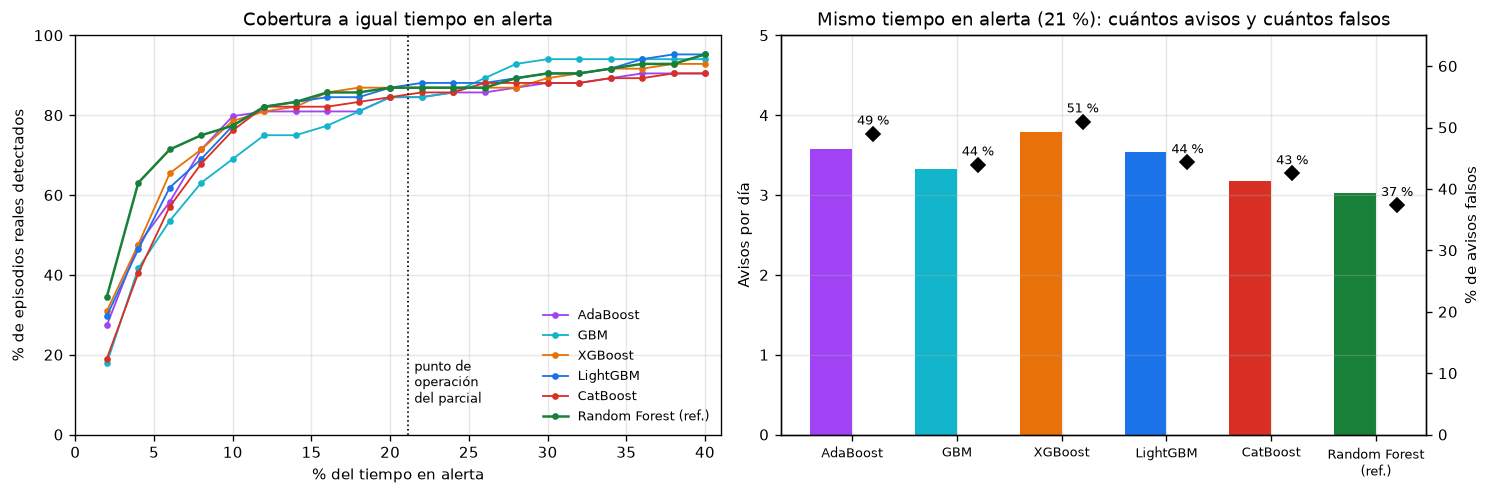

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
for nombre in orden_c:
    c = CURVAS[nombre]
    ax[0].plot(c["presupuesto"], c["eventos detectados %"], "o-", ms=3, lw=1.5 if "ref" in nombre else 1.1,
               color=COL[nombre], label=nombre, zorder=3 if "ref" in nombre else 2)
ax[0].axvline(OP["tiempo en alerta %"], color="k", ls=":", lw=1)
ax[0].text(OP["tiempo en alerta %"] + .4, 8, "punto de\noperación\ndel parcial", fontsize=7.5)
ax[0].set(xlabel="% del tiempo en alerta", ylabel="% de episodios reales detectados", xlim=(0, 41), ylim=(0, 100),
          title="Cobertura a igual tiempo en alerta")
ax[0].legend(frameon=False, fontsize=7.5, loc="lower right")

t = TAB_EP["del parcial (21,1 %)"].loc[orden_c]
x = np.arange(len(orden_c))
ax[1].bar(x - .2, t["avisos/día"], .4, color=[COL[m] for m in orden_c], label="Avisos por día")
ax2 = ax[1].twinx()
ax2.plot(x + .2, t["avisos falsos %"], "D", color="k", ms=6, label="% de avisos falsos")
for i, v in enumerate(t["avisos falsos %"]):
    ax2.text(i + .2, v + 1.5, f"{v:.0f} %", ha="center", fontsize=7.5)
ax2.set_ylim(0, 65); ax2.set_ylabel("% de avisos falsos"); ax2.grid(False)
ax[1].set_xticks(x, [m.replace(" (ref.)", "\n(ref.)") for m in orden_c], fontsize=8)
ax[1].set(ylim=(0, 5), ylabel="Avisos por día", title="Mismo tiempo en alerta (21 %): cuántos avisos y cuántos falsos")
plt.tight_layout(); plt.savefig(FIG / "B3_detector.png"); plt.show()

**Como lo usaría Shiro, el detector no cambia.**

**Primero, una corrección al protocolo del parcial.** El parcial comparó detectores con el mismo
número de avisos por día, y esa medida se puede ganar con trampa: con un umbral de 0,05, el GBM
«detecta» el 98,8 % de los episodios con unos tres avisos diarios — porque cada aviso es un bloque de
más de cinco horas (317 minutos de media), el sistema pasa el 67,5 % del tiempo en alerta y el 62 % de
los avisos son falsos. Lo justo es comparar con el mismo **tiempo en alerta**.

**El punto de operación del parcial, visto así.** Random Forest con umbral 0,40 pasa el **21,1 % del
tiempo en alerta**, con avisos de **100 minutos de media**. Da 3,0 avisos al día y detecta el 86,9 %
de los episodios, como decía el parcial; lo que el parcial no dijo es cuánto dura cada aviso.

**Con el mismo tiempo en alerta, ningún boosting mejora al bosque.** Al 21,1 %, todos detectan entre
el 84,5 y el 88,1 % de los episodios; Random Forest lo hace con **menos avisos (3,03 al día) y menos
avisos falsos (37,3 %)**, mientras que los boostings reparten el mismo tiempo en más avisos (3,18 a
3,80 al día), más cortos y más a menudo falsos (42,5 a 51,0 %). Con presupuestos ajustados el bosque
detecta más: con un 4 % del tiempo en alerta, el 63,1 % de los episodios frente a un 47,6 % como
máximo en los boostings. Solo en el presupuesto igual a la tasa real de anomalías (8,2 %) XGBoost
supera al bosque, por poco (76,2 % frente a 75,0 %).

**Es la misma lección del parcial, ahora con cinco modelos más.** El boosting ordena mejor las
lecturas una a una, pero eso no se traduce en detectar más episodios ni en molestar menos: sus
probabilidades se reparten dentro de cada episodio de forma que el mismo tiempo en alerta se
fragmenta en más avisos. La métrica del curso y la métrica del producto vuelven a elegir modelos
distintos.

---
## 6. De qué bloque aprende el mejor boosting

Importancia por bloque de LightGBM en la partición temporal con retardos, medida por ganancia —
nunca por sensor individual, por la advertencia §8 sobre variables correlacionadas.

Importancia por bloque (LightGBM, ganancia, temporal + retardos):
Retardos      86.5
Temporales     2.2
lights         0.3
Interiores     8.9
Clima          2.1
Solo lag1: 74.9 %


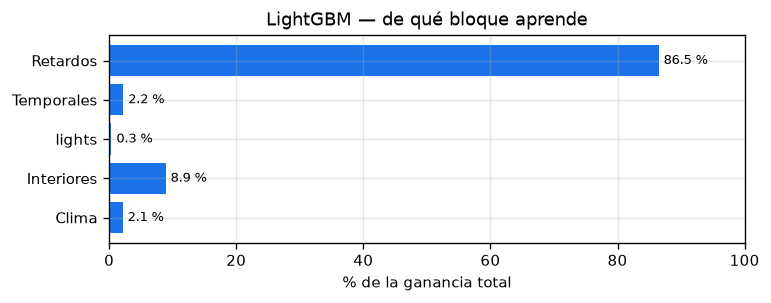

In [12]:
# Importancia por bloque (advertencia §8: nunca por sensor individual) del mejor boosting de regresión
Xtr, ytr, Xte, yte, modo = ESCENARIOS["Temporal + retardos"]
Xa, Xv, ya, yv = dividir_val(Xtr, ytr, modo)
m_imp = lgb.LGBMRegressor(n_estimators=3000, learning_rate=.05, num_leaves=31, subsample=.8, subsample_freq=1,
                          colsample_bytree=.8, random_state=RS, verbose=-1, importance_type="gain")
m_imp.fit(Xa, ya, eval_set=[(Xv, yv)], callbacks=[lgb.early_stopping(100, verbose=False)])
imp = pd.Series(m_imp.feature_importances_, index=Xtr.columns)
bloques = {"Retardos": RETARDOS, "Temporales": TEMPORALES, "lights": ["lights"], "Interiores": INTERIOR, "Clima": CLIMA}
imp_b = pd.Series({b: imp[c].sum() for b, c in bloques.items()}) / imp.sum() * 100
print("Importancia por bloque (LightGBM, ganancia, temporal + retardos):")
print(imp_b.round(1).to_string())
print(f"Solo lag1: {imp['lag1'] / imp.sum() * 100:.1f} %")
fig, ax = plt.subplots(figsize=(6.5, 2.6))
ax.barh(imp_b.index[::-1], imp_b.values[::-1], color="#1a73e8")
for i, v in enumerate(imp_b.values[::-1]):
    ax.text(v + .8, i, f"{v:.1f} %", va="center", fontsize=8)
ax.set(xlabel="% de la ganancia total", xlim=(0, 100), title="LightGBM — de qué bloque aprende")
plt.tight_layout(); plt.savefig(FIG / "B4_importancia.png"); plt.show()

El **86,5 %** de su ganancia viene de los retardos —el
74,9 % solo de `lag1`—: el mejor boosting aprende casi lo mismo que la regresión lineal, y lo poco que
añade viene sobre todo de los sensores interiores (8,9 %), justo el bloque que introduce el sesgo
estacional de §4.3. Por eso empata con la lineal y no la supera.

---

## Cierre — qué cambia en el diseño de Shiro por causa de estos números

1. **El simulador no cambia: regresión lineal con retardos.** El mejor boosting (LightGBM) la iguala
   en la partición temporal (R² 0,554 frente a 0,557) sin superarla, con más error medio y un sesgo
   de +9 Wh. Entre un conjunto de 50 árboles y una fórmula lineal que rinde igual, la lineal gana por
   interpretabilidad, velocidad y ausencia de sesgo.
2. **El detector no cambia: Random Forest con retardos.** Con el mismo tiempo en alerta, ningún
   boosting detecta claramente más episodios, y todos avisan más veces y con más avisos falsos.
3. **Se identificó por qué los árboles fallan en el tiempo.** El 71,9 % de las lecturas de mayo son más
   cálidas que cualquiera del entrenamiento, y en invierno «casa cálida» significaba «consumo alto».
   Sin las temperaturas, el sesgo desaparece. La temperatura interior entra al MDP como variable de
   confort, no como predictor de consumo.
4. **Corrección metodológica: el detector se evalúa con el mismo tiempo en alerta.** El presupuesto
   de avisos por día se podía ganar con alertas larguísimas. El punto de operación del parcial deja al
   sistema en alerta el 21 % del día, con avisos de 100 minutos: el control de umbral de la interfaz
   debería mostrar también el tiempo en alerta, no solo cuántos avisos.
5. **Las métricas del curso vuelven a elegir otro modelo.** Por average precision y AUC gana el
   boosting; por lo que vive la persona, el bosque.
6. **Hojas lineales, no; hora categórica, no aporta; AdaBoost no puede hacer boosting en regresión**
   (1 a 14 árboles). El pendiente de codificar la hora queda solo para KNN.
7. **El boosting gana la partición aleatoria** (LightGBM 0,598, el mejor del proyecto en esa
   partición) — un número que, por la regla del proyecto, se reporta pero no decide.

**Lo que sigue:** formalizar el MDP con la función de transición ya decidida (lineal con retardos),
y probar si el detector de Random Forest también mejora sin las temperaturas interiores.